# picomake - mlp

In [289]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [290]:
words = open('names.txt', 'r').read().split()
len(words)

32033

In [291]:
# build vocab stoi and itos dictionaries for character level indexing 

chars = set(sorted(letter for w in words for letter in w))

stoi = {s:i+1 for i,s in enumerate(sorted(chars))}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

### what am i doing? 

<small>

in the next cell, we shall build out the context window. its a custom set rolling window across each word. lets say context_size = 3, and the word is emma. the first window produces '000' next one produces, '005' and so on using stoi. X tensor is basically the whole set of this. Y tensor is the next character that is expected after the context window. 

after that, we use an embedding matrix of randomly initialised values to index the values to get the nn to work correctly. if a - 1 and z - 27, and the neural net learns a and z via the relative distance between the two. and in real language semantics, this contains no meaning. thats why we have an embedding table.

</small>

In [292]:
# build out dataset
def build_dataset(words):
    context_size = 3
    X = []
    Y = []

    for w in words:
        context = [0]*context_size

        for i in w+'.':
            ix = stoi[i]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context [1:] + [ix]


    X = torch.tensor(X) # X stores the context of one training example in chunk of context size (stoi)
    Y = torch.tensor(Y) # Y stores the stoi value of each char in the word
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [293]:
print(Xtr.shape)
print(Ytr.shape)

# how the word 'emma' is stored in x:
Xtr[:5]


torch.Size([182625, 3])
torch.Size([182625])


tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        [25, 21,  8],
        [21,  8,  5]])

In [294]:
# let us create an embedding matrix where every character 
# gets a 2 dimensional embedding using the awesome pytorch indexing
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
emb = C[Xtr]


print(f"c for emma  = {C[:5]}")
print(f"emb for emma = {emb[:5]}")

c for emma  = tensor([[ 1.5674, -0.2373],
        [-0.0274, -1.1008],
        [ 0.2859, -0.0296],
        [-1.5471,  0.6049],
        [ 0.0791,  0.9046]])
emb for emma = tensor([[[ 1.5674, -0.2373],
         [ 1.5674, -0.2373],
         [ 1.5674, -0.2373]],

        [[ 1.5674, -0.2373],
         [ 1.5674, -0.2373],
         [-0.4713,  0.7868]],

        [[ 1.5674, -0.2373],
         [-0.4713,  0.7868],
         [ 2.4448, -0.6701]],

        [[-0.4713,  0.7868],
         [ 2.4448, -0.6701],
         [ 2.4448, -0.6701]],

        [[ 2.4448, -0.6701],
         [ 2.4448, -0.6701],
         [-0.0274, -1.1008]]])


### lets do a breakdown for the first training example

<small>

so first, we can see the **X tensor values for 'emma'** is :

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])

**now C for 'emma'** is :

c for emma  = tensor([[ 1.1651, -0.5914],
        [-0.1032, -1.2893],
        [ 0.3337,  0.5309],
        [ 0.8997, -0.5117],
        [-0.0375, -0.2484]])

**now emb values for 'emma'** is :

emb for emma = tensor([[[ 1.1651, -0.5914],
         [ 1.1651, -0.5914],
         [ 1.1651, -0.5914]],

        [[ 1.1651, -0.5914],
         [ 1.1651, -0.5914],
         [ 0.4197, -0.8437]],

        [[ 1.1651, -0.5914],
         [ 0.4197, -0.8437],
         [ 1.5876, -0.0741]],

        [[ 0.4197, -0.8437],
         [ 1.5876, -0.0741],
         [ 1.5876, -0.0741]],

        [[ 1.5876, -0.0741],
         [ 1.5876, -0.0741],
         [-0.1032, -1.2893]]])

as you can see, x tensor values was [0,0,0] at 0 index, when C[X] done, it gave [C[0], C[0], C[0]] which is :

        [[ 1.1651, -0.5914],
         [ 1.1651, -0.5914],
         [ 1.1651, -0.5914]],

this is how the embeddings are used for representation learning. in the coming cells, I will probably backprop and update our embedding matrix as the model has to inherently learn the vector space representation for each letter by itself so predicting is free from any IDs associated with that letter :)

*quite the advantage :)*


</small>

In [295]:
print(emb.shape)

torch.Size([228146, 3, 2])


In [296]:
# first hidden layer

# incoming dims = torch.Size([228146, 3, 2])

W1 = torch.randn((6, 100), generator=g) # 6,100 wants to get multiplied to torch.Size([5, 3, 2]) first word say
b1 = torch.randn(100, generator=g)


# we can do torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1) or

# torch.cat(torch.unbind(emb, 1), 1).shape # unbind removes the dimension and flattens it and cat concatenates along the flattened dimension

# lets use .view for the tensor for ease

h1 = emb.view(-1, 6) @ W1 + b1 # -1 means any rows
h1 = torch.tanh(h1)
h1.shape


torch.Size([228146, 100])

In [297]:
# second hidden layer (last layer)

# incoming dims = torch.Size([228146, 100])

W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
logits = h1@W2 + b2


parameters = (C, W1, b1, W2, b2)


In [298]:
# compare with Y tensor and creating negative average log loss

# Y[0] is the stuff we need to predict for, and  probs[torch.arange(228146), Y] returns the probability assigned to it before training

# probs = h2/h2.sum(1, keepdim=True)
# probs[:2]
# loss = -(probs[torch.arange(228146), Y]).log().mean()

# but lets use cross-entropy from torch.nn.functional

loss = F.cross_entropy(logits, Y)
loss

tensor(19.5052)

### final training loop

In [316]:
# prepare out training data

W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
C = torch.randn((27,10), generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = (C, W1, b1, W2, b2)

print(f"number of parameters = {sum(p.nelement() for p in parameters)}")

for p in parameters:
    p.requires_grad = True

# finding a good lr
lre = torch.linspace(-3, 0, 30000)
lre = 10**lre


number of parameters = 17697


In [322]:
# =================================FULL TRAINING LOOP================================#

losses = []
lrs = []
steps = []

for i in range(500000):

    # batch gradient descent

    ix = torch.randint(0, Xtr.shape[0], (64, ))

    # forward pass
    emb = C[Xtr[ix]]

    h1 = emb.view(-1, 30) @ W1 + b1 # -1 means any rows
    h1 = torch.tanh(h1)

    logits = h1@W2 + b2

    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    # set grad = None
    for p in parameters:
        p.grad = None

    loss.backward()

    # optimise
    # lr = lre[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    #track
    losses.append(loss.log10().item())
    lrs.append(lr)
    steps.append(i)
    

print(loss.item())

1.9264552593231201


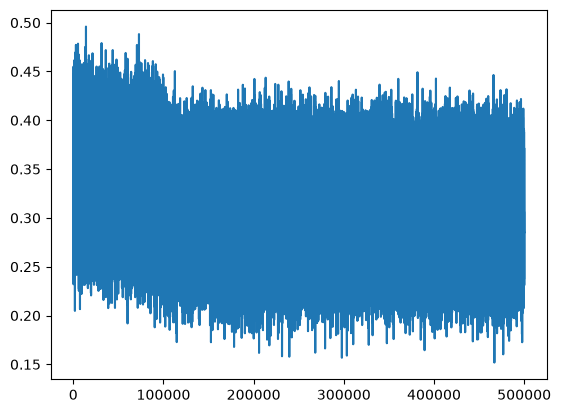

In [323]:
plt.plot(steps, losses)

In [324]:
# validation tests

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
losstrain = F.cross_entropy(logits, Ytr)

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
lossval = F.cross_entropy(logits, Ydev)

# if nearly same, our network is underfitting. scaling up the model.
print(f"training loss - {losstrain}\n validation loss - {lossval}")


training loss - 2.04362154006958
 validation loss - 2.136122465133667


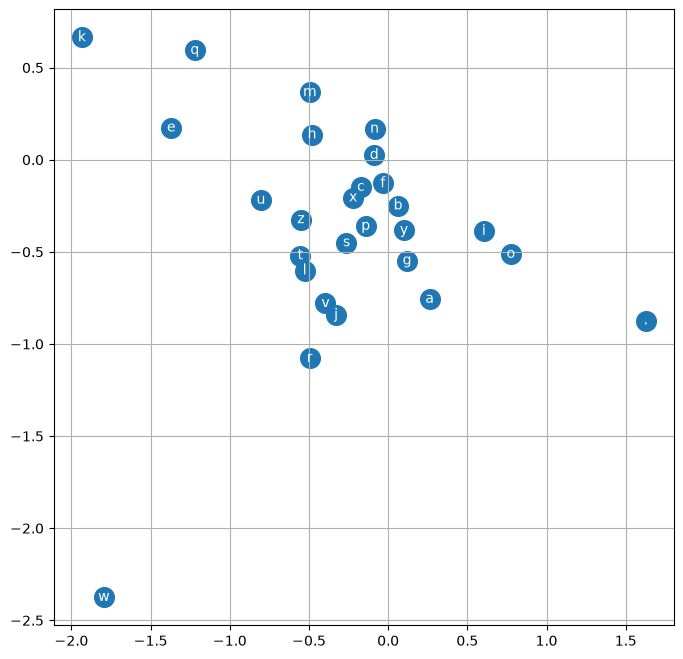

In [325]:
# visualise embeddings in 2d

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [330]:
#sampling 
for _ in range(20):
    
    out = []
    context = [0] * 3 # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

kameiron.
satuj.
davon.
anfa.
rexon.
hir.
avter.
beabhi.
shaylin.
nis.
kypincenis.
arosemer.
characlyn.
khassarent.
yaren.
kashino.
aryahi.
rey.
daimina.
aeda.


### beats karpathy's hyperparameter tuning (comparison below):

<small>

my setup overfits the training data slightly but has a reasonably good loss on the validation split.

heres the difference:

his hidden layer has 200 neurons. mine has 300. both running the same 10 dimensional embedding space. He has a smaller batch for gradient descent at 32 while i have it as 64. He trains for 300000 epochs while I did for 500000.

his val loss - 2.1701
mine - 2.136122465133667

reference - [Timestamp in the original makemore implementation :) ](https://youtu.be/TCH_1BHY58I?t=4318)

</small>

#### looking back

<small>

quite a few takeways. a lot of good practices like splitting and tuning properly with reason. The embedding matrix got me lost a couple of hours. but now i get it why its needed after the backward pass implementation :)

a pretty nice run I would say.

11:56pm 16/09/2026
</small>